In [4]:
from tensorflow.keras.models import load_model

model = load_model("/content/best_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [5]:
import os
import json

os.environ['KAGGLE_USERNAME'] = "chandramoulibandaru"
os.environ['KAGGLE_KEY'] = "KGAT_4eed677cb21afe63d661c7c029b2a68a"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "chandramoulibandaru", "key": "KGAT_4eed677cb21afe63d661c7c029b2a68a"}, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)



In [6]:
!kaggle datasets download abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:11<00:00, 191MB/s]



In [7]:
import zipfile
unzip_file_path='/content/plantvillage-dataset.zip'


In [8]:
with zipfile.ZipFile(unzip_file_path,'r') as unzip:
  unzip.extractall('/content/dataset')



In [9]:
import os

dataset_path = "/content/dataset/plantvillage dataset"

print(os.listdir(dataset_path))

['segmented', 'color', 'grayscale']


In [10]:
dataset_path = "/content/dataset/plantvillage dataset/color"

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [12]:
class_names = list(train_data.class_indices.keys())

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_sp

In [14]:
import os

img_path = val_data.filepaths[0]

print("Image:", img_path)
print("Actual class:", class_names[val_data.classes[0]])

Image: /content/dataset/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
Actual class: Apple___Apple_scab


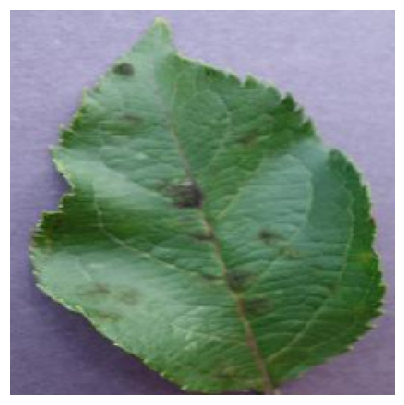

In [15]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

img = load_img(img_path, target_size=(224, 224))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [16]:
from lime import lime_image
import numpy as np

explainer = lime_image.LimeImageExplainer()

In [17]:
def predict_fn(images):
    images = np.array(images)
    return model.predict(images)

In [18]:
explanation = explainer.explain_instance(
    np.array(img) / 255.0,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━

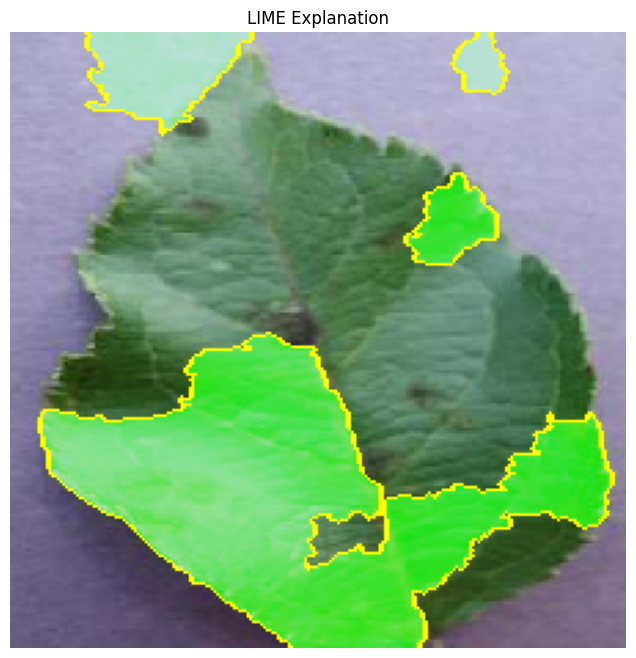

In [19]:
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(8, 8))
plt.imshow(mark_boundaries(temp, mask))
plt.axis("off")
plt.title("LIME Explanation")
plt.show()

In [20]:
!nvidia-smi

Fri Sep 18 07:26:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             29W /   70W |    1149MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
!git clone https://github.com/sunsmarterjie/yolov12.git

Cloning into 'yolov12'...
remote: Enumerating objects: 1179, done.
remote: Counting objects: 100% (408/408), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 1179 (delta 339), reused 328 (delta 327), pack-reused 771 (from 1)
Receiving objects: 100% (1179/1179), 1.90 MiB | 21.40 MiB/s, done.
Resolving deltas: 100% (549/549), done.


In [23]:
%cd yolov12

/content/yolov12


In [25]:
!pip install -r requirements.txt
!pip install -e .

ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Obtaining file:///content/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20189 sha256=92862914baab1bf29f695e371f87ce221b9221635661a4302342a5ed4d01e43f
  Stored in directory: /tmp/pip-ephem-wheel-cache-93x765x9/wheels/c3/25/fe/5d5ee73f6727e388cc83168c9253608dba97527fcecf4cf27e
Successfully built ultralytics


In [26]:
from ultralytics import YOLO

model = YOLO("yolov12n.yaml")

print("YOLOv12 loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
YOLOv12 loaded successfully!




image 1/1 /content/tomatoes.jpg: 640x480 1 person, 57.2ms
image 1/1 /content/tomatoes.jpg: 640x480 1 person, 57.2ms
Speed: 2.5ms preprocess, 57.2ms inference, 260.5ms postprocess per image at shape (1, 3, 640, 480)
Speed: 2.5ms preprocess, 57.2ms inference, 260.5ms postprocess per image at shape (1, 3, 640, 480)


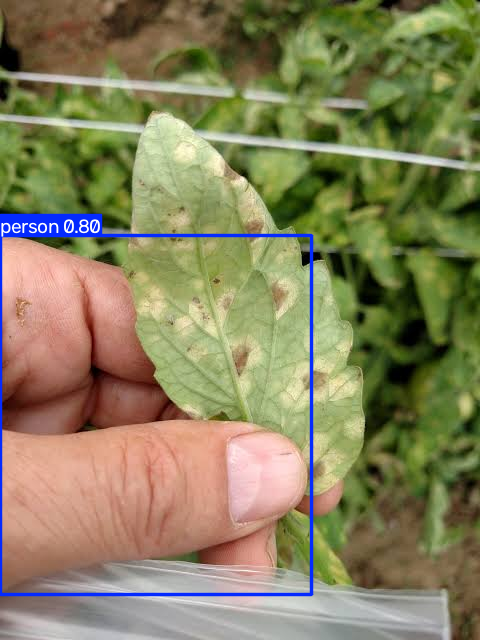

In [28]:
from ultralytics import YOLO

model = YOLO("yolov12n.pt")

results = model("/content/tomatoes.jpg")

results[0].show()

In [29]:
%cd /content

!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git


/content
Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 45.75 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


In [30]:
!ls /content/PlantDoc-Dataset

LICENSE.txt  PlantDoc_Examples.png  README.md  test  train


In [31]:
import os

train_path = "/content/PlantDoc-Dataset/train"

print(os.listdir(train_path)[:20])

['Bell_pepper leaf', 'Corn rust leaf', 'Tomato leaf mosaic virus', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'grape leaf', 'Raspberry leaf', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'Potato leaf early blight', 'Apple rust leaf', 'grape leaf black rot', 'Apple Scab Leaf', 'Tomato leaf bacterial spot', 'Soyabean leaf', 'Potato leaf late blight', 'Cherry leaf', 'Bell_pepper leaf spot', 'Tomato two spotted spider mites leaf']


In [32]:
test_path = "/content/PlantDoc-Dataset/test"

print(os.listdir(test_path)[:20])

['Bell_pepper leaf', 'Corn rust leaf', 'Tomato leaf mosaic virus', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'grape leaf', 'Raspberry leaf', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'Potato leaf early blight', 'Apple rust leaf', 'grape leaf black rot', 'Apple Scab Leaf', 'Tomato leaf bacterial spot', 'Soyabean leaf', 'Potato leaf late blight', 'Cherry leaf', 'Bell_pepper leaf spot', 'Squash Powdery mildew leaf']


In [33]:
%cd /content

!git clone https://github.com/pratikkayal/PlantDoc-Object-Detection-Dataset.git

/content
Cloning into 'PlantDoc-Object-Detection-Dataset'...
remote: Enumerating objects: 5196, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5196 (delta 56), reused 54 (delta 54), pack-reused 5127 (from 1)
Receiving objects: 100% (5196/5196), 941.88 MiB | 44.08 MiB/s, done.
Resolving deltas: 100% (2443/2443), done.
Updating files: 100% (5200/5200), done.


In [34]:
!ls /content/PlantDoc-Object-Detection-Dataset

LICENSE.txt  README.md	TEST  test_labels.csv  TRAIN  train_labels.csv


In [35]:
import pandas as pd

train_csv = "/content/PlantDoc-Object-Detection-Dataset/train_labels.csv"

df = pd.read_csv(train_csv)

print(df.head())
print("\nColumns:")
print(df.columns.tolist())

                                 filename  width  height        class  xmin  \
0       cherry-tree-leaves-and-fruits.jpg    350     300  Cherry leaf   198   
1       cherry-tree-leaves-and-fruits.jpg    350     300  Cherry leaf     3   
2       cherry-tree-leaves-and-fruits.jpg    350     300  Cherry leaf    30   
3       cherry-tree-leaves-and-fruits.jpg    350     300  Cherry leaf   226   
4  peach-and-leaf-stock-image-2809275.jpg   1300    1099   Peach leaf   237   

   ymin  xmax  ymax  
0    77   299   252  
1   114   148   235  
2   184   189   297  
3     4   346    83  
4   479   527   810  

Columns:
['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']


In [37]:
import os
import pandas as pd

base_path = "/content/PlantDoc-Object-Detection-Dataset"

train_img_dir = os.path.join(base_path, "TRAIN")
test_img_dir = os.path.join(base_path, "TEST")

train_csv = os.path.join(base_path, "train_labels.csv")
test_csv = os.path.join(base_path, "test_labels.csv")

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

classes = sorted(
    set(train_df["class"].unique()) |
    set(test_df["class"].unique())
)

class_to_id = {name: i for i, name in enumerate(classes)}

print("Number of classes:", len(classes))
print("Classes:")
for i, name in enumerate(classes):
    print(i, ":", name)


Number of classes: 29
Classes:
0 : Apple Scab Leaf
1 : Apple leaf
2 : Apple rust leaf
3 : Bell_pepper leaf
4 : Bell_pepper leaf spot
5 : Blueberry leaf
6 : Cherry leaf
7 : Corn Gray leaf spot
8 : Corn leaf blight
9 : Corn rust leaf
10 : Peach leaf
11 : Potato leaf
12 : Potato leaf early blight
13 : Potato leaf late blight
14 : Raspberry leaf
15 : Soyabean leaf
16 : Squash Powdery mildew leaf
17 : Strawberry leaf
18 : Tomato Early blight leaf
19 : Tomato Septoria leaf spot
20 : Tomato leaf
21 : Tomato leaf bacterial spot
22 : Tomato leaf late blight
23 : Tomato leaf mosaic virus
24 : Tomato leaf yellow virus
25 : Tomato mold leaf
26 : Tomato two spotted spider mites leaf
27 : grape leaf
28 : grape leaf black rot


In [38]:
yolo_base = "/content/plantdoc_yolo"

os.makedirs(f"{yolo_base}/images/train", exist_ok=True)
os.makedirs(f"{yolo_base}/images/val", exist_ok=True)
os.makedirs(f"{yolo_base}/labels/train", exist_ok=True)
os.makedirs(f"{yolo_base}/labels/val", exist_ok=True)

print("YOLO folders created!")

YOLO folders created!


In [39]:
import shutil

def convert_to_yolo(df, image_dir, split):

    grouped = df.groupby("filename")

    for filename, group in grouped:

        image_path = os.path.join(image_dir, filename)

        if not os.path.exists(image_path):
            continue

        # Copy image
        destination_image = f"{yolo_base}/images/{split}/{filename}"
        shutil.copy2(image_path, destination_image)

        # Image dimensions
        img_width = group.iloc[0]["width"]
        img_height = group.iloc[0]["height"]

        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = f"{yolo_base}/labels/{split}/{label_filename}"

        with open(label_path, "w") as f:

            for _, row in group.iterrows():

                class_id = class_to_id[row["class"]]

                xmin = row["xmin"]
                ymin = row["ymin"]
                xmax = row["xmax"]
                ymax = row["ymax"]

                # Convert to YOLO format
                x_center = ((xmin + xmax) / 2) / img_width
                y_center = ((ymin + ymax) / 2) / img_height

                box_width = (xmax - xmin) / img_width
                box_height = (ymax - ymin) / img_height

                f.write(
                    f"{class_id} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{box_width:.6f} "
                    f"{box_height:.6f}\n"
                )


convert_to_yolo(
    train_df,
    train_img_dir,
    "train"
)

convert_to_yolo(
    test_df,
    test_img_dir,
    "val"
)

print("Conversion completed!")

/tmp/ipykernel_4561/3626440547.py:37: RuntimeWarning: divide by zero encountered in divide
  x_center = ((xmin + xmax) / 2) / img_width
/tmp/ipykernel_4561/3626440547.py:38: RuntimeWarning: divide by zero encountered in divide
  y_center = ((ymin + ymax) / 2) / img_height
/tmp/ipykernel_4561/3626440547.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  box_width = (xmax - xmin) / img_width
/tmp/ipykernel_4561/3626440547.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  box_height = (ymax - ymin) / img_height


Conversion completed!


In [40]:
import yaml

data = {
    "path": yolo_base,
    "train": "images/train",
    "val": "images/val",
    "nc": len(classes),
    "names": classes
}

with open(f"{yolo_base}/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(open(f"{yolo_base}/data.yaml").read())

path: /content/plantdoc_yolo
train: images/train
val: images/val
nc: 29
names:
- Apple Scab Leaf
- Apple leaf
- Apple rust leaf
- Bell_pepper leaf
- Bell_pepper leaf spot
- Blueberry leaf
- Cherry leaf
- Corn Gray leaf spot
- Corn leaf blight
- Corn rust leaf
- Peach leaf
- Potato leaf
- Potato leaf early blight
- Potato leaf late blight
- Raspberry leaf
- Soyabean leaf
- Squash Powdery mildew leaf
- Strawberry leaf
- Tomato Early blight leaf
- Tomato Septoria leaf spot
- Tomato leaf
- Tomato leaf bacterial spot
- Tomato leaf late blight
- Tomato leaf mosaic virus
- Tomato leaf yellow virus
- Tomato mold leaf
- Tomato two spotted spider mites leaf
- grape leaf
- grape leaf black rot



In [41]:
%cd /content/yolov12

/content/yolov12


In [42]:
from ultralytics import YOLO

model = YOLO("yolov12n.yaml")

In [43]:
results = model.train(
    data="/content/plantdoc_yolo/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    name="plantdoc_yolov12"
)

New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.yaml, data=/content/plantdoc_yolo/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=plantdoc_yolov12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, h

100%|██████████| 755k/755k [00:00<00:00, 28.2MB/s]


Overriding model.yaml nc=80 with nc=29
Overriding model.yaml nc=80 with nc=29

                   from  n    params  module                                       arguments                     

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3     

train: Scanning /content/plantdoc_yolo/labels/train... 2342 images, 0 backgrounds, 5 corrupt: 100%|██████████| 2342/2342 [00:02<00:00, 936.00it/s] 

train: WARNING ⚠️ /content/plantdoc_yolo/images/train/0008003-strawberry-leaf-veiner-large.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/20170524_195105-1k1eu8b.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2195890.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2976_1600.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2f73110f80014a25a53f9551c94bf164.png.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [inf inf inf inf]
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/Early-blight.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.439759]
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/SouthernRustLeaf.png.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [inf inf inf inf]
train: WARNING ⚠️ /content/plantdoc_yolo

...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      10/10      3.79G      2.191      4.344      2.705          1        640: 100%|██████████| 147/147 [01:07<00:00,  2.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:04<00:00,  1.81it/s]


                   all        236        452      0.512     0.0645     0.0476     0.0236
                   all        236        452      0.512     0.0645     0.0476     0.0236

10 epochs completed in 0.224 hours.

10 epochs completed in 0.224 hours.
Optimizer stripped from /content/yolov12/runs/detect/plantdoc_yolov12/weights/last.pt, 5.4MB
Optimizer stripped from /content/yolov12/runs/detect/plantdoc_yolov12/weights/last.pt, 5.4MB
Optimizer stripped from /content/yolov12/runs/detect/plantdoc_yolov12/weights/best.pt, 5.4MB
Optimizer stripped from /content/yolov12/runs/detect/plantdoc_yolov12/weights/best.pt, 5.4MB

Validating /content/yolov12/runs/detect/plantdoc_yolov12/weights/best.pt...

Validating /content/yolov12/runs/detect/plantdoc_yolov12/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 376 layers, 2,513,999 paramete

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:04<00:00,  1.83it/s]


                   all        236        452      0.549      0.062     0.0476     0.0235
                   all        236        452      0.549      0.062     0.0476     0.0235
       Apple Scab Leaf         10         13          1          0     0.0184     0.0086
       Apple Scab Leaf         10         13          1          0     0.0184     0.0086
            Apple leaf          9         10          0          0      0.011    0.00551
            Apple leaf          9         10          0          0      0.011    0.00551
       Apple rust leaf         10         11          1          0     0.0403     0.0253
       Apple rust leaf         10         11          1          0     0.0403     0.0253
      Bell_pepper leaf          8         11          0          0    0.00128    0.00047
      Bell_pepper leaf          8         11          0          0    0.00128    0.00047
 Bell_pepper leaf spot          9         15          1          0    0.00652    0.00372
 Bell_pepper leaf spo

In [44]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/yolov12/runs/detect/plantdoc_yolov12/weights/best.pt"
)

print("YOLOv12 model loaded!")

YOLOv12 model loaded!


In [45]:
from google.colab import files

uploaded = files.upload()

Saving tomatoes(1).jpg to tomatoes(1).jpg




image 1/1 /content/yolov12/tomatoes(1).jpg: 640x480 (no detections), 64.5ms
image 1/1 /content/yolov12/tomatoes(1).jpg: 640x480 (no detections), 64.5ms
Speed: 2.0ms preprocess, 64.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Speed: 2.0ms preprocess, 64.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/yolov12/runs/detect/predict
Results saved to /content/yolov12/runs/detect/predict


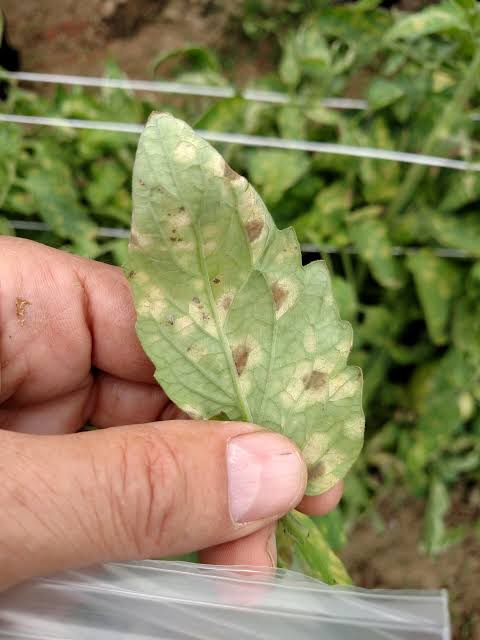

In [46]:
image_name = list(uploaded.keys())[0]

results = best_model.predict(
    source=image_name,
    conf=0.05,
    save=True
)

results[0].show()

In [47]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    print(
        f"Detected: {classes[class_id]} | "
        f"Confidence: {confidence:.3f}"
    )

In [48]:
results = best_model.predict(
    source=image_name,
    conf=0.05,
    save=True
)

if len(results[0].boxes) == 0:
    print("❌ No objects detected")
else:
    print("✅ Detections found:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        print(f"{classes[class_id]} → {confidence:.2f}")



image 1/1 /content/yolov12/tomatoes(1).jpg: 640x480 (no detections), 18.3ms
image 1/1 /content/yolov12/tomatoes(1).jpg: 640x480 (no detections), 18.3ms
Speed: 2.3ms preprocess, 18.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
Speed: 2.3ms preprocess, 18.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/yolov12/runs/detect/predict
Results saved to /content/yolov12/runs/detect/predict
❌ No objects detected


In [49]:
import glob

val_images = glob.glob("/content/plantdoc_yolo/images/val/*")

print("Number of validation images:", len(val_images))
print("Example:", val_images[0])

Number of validation images: 236
Example: /content/plantdoc_yolo/images/val/apples_apple-scab_02_thm.jpg




image 1/1 /content/plantdoc_yolo/images/val/apples_apple-scab_02_thm.jpg: 480x640 (no detections), 64.8ms
image 1/1 /content/plantdoc_yolo/images/val/apples_apple-scab_02_thm.jpg: 480x640 (no detections), 64.8ms
Speed: 2.3ms preprocess, 64.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Speed: 2.3ms preprocess, 64.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/yolov12/runs/detect/predict
Results saved to /content/yolov12/runs/detect/predict


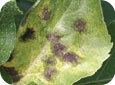

In [50]:
test_image = val_images[0]

results = best_model.predict(
    source=test_image,
    conf=0.05,
    save=True
)

results[0].show()

In [51]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    print(f"Detected: {classes[class_id]} | Confidence: {confidence:.3f}")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/yolov12/runs/detect/plantdoc_yolov12/weights/last.pt")

results = model.train(
    data="/content/plantdoc_yolo/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    name="plantdoc_yolov12_more"
)

New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
New https://pypi.org/project/ultralytics/8.4.155 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Ultralytics 8.3.63 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/content/yolov12/runs/detect/plantdoc_yolov12/weights/last.pt, data=/content/plantdoc_yolo/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=plantdoc_yolov12_more, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, 

train: Scanning /content/plantdoc_yolo/labels/train.cache... 2342 images, 0 backgrounds, 5 corrupt: 100%|██████████| 2342/2342 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/plantdoc_yolo/images/train/0008003-strawberry-leaf-veiner-large.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/20170524_195105-1k1eu8b.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2195890.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2976_1600.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/2f73110f80014a25a53f9551c94bf164.png.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [inf inf inf inf]
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/Early-blight.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.439759]
train: WARNING ⚠️ /content/plantdoc_yolo/images/train/SouthernRustLeaf.png.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [inf inf inf inf]
train: WARNING ⚠️ /content/plantdoc_yolo


/content/yolov12/ultralytics/data/augment.py:1853: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/plantdoc_yolo/labels/val.cache... 236 images, 0 backgrounds, 0 corrupt: 100%|██████████| 236/236 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/plantdoc_yolo/images/val/02.-Rust-2017-207u24s.jpg: corrupt JPEG restored and saved


val: WARNING ⚠️ /content/plantdoc_yolo/images/val/02.-Rust-2017-207u24s.jpg: corrupt JPEG restored and saved
Plotting labels to /content/yolov12/runs/detect/plantdoc_yolov12_more/labels.jpg... 
Plotting labels to /content/yolov12/runs/detect/plantdoc_yolov12_more/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000303, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
optimizer: AdamW(lr=0.000303, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
L

       1/50      3.85G      2.495      4.401      2.893        112        640:  73%|███████▎  | 107/147 [00:56<00:17,  2.27it/s]